In [2]:
import pandas as pd
df = pd.read_csv("gymExercise_dataset.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


# ETAPAS 4 - 5 - 6

Instalación librerías en el entorno python
- pip install matplotlib
- pip install scikit-learn

# Etapa 4 - Analítica descriptiva y diagnóstica

## Analítica descriptiva: estadísticas generales (describe)

In [2]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


calcula de una sola vez el conteo, promedio, desviación estándar, mínimo, máximo y cuartiles de todas las columnas numéricas (Age, Weight, Height, BPMs, Session_Duration, Calories_Burned, Fat_Percentage, Water_Intake, Workout_Frequency, Experience_Level, BMI). Esto da un panorama rápido de la dispersión de los datos: por ejemplo, permite ver si hay valores extremos en Calories_Burned o si el rango de edades es amplio. Es la base de la analítica descriptiva porque resume "qué pasó" en los datos sin explicar todavía el "por qué".

## Analítica descriptiva: métricas puntuales (suma, promedio, máximo, mínimo)

In [ ]:
#calorías quemadas
promedio_calorias = df["Calories_Burned"].mean()
maximo_calorias = df["Calories_Burned"].max()
minimo_calorias = df["Calories_Burned"].min()

print("Promedio de calorías quemadas:", round(promedio_calorias, 2))
print("Máximo de calorías quemadas:", maximo_calorias)
print("Mínimo de calorías quemadas:", minimo_calorias)

Promedio de calorías quemadas: 905.42
Máximo de calorías quemadas: 1783.0
Mínimo de calorías quemadas: 303.0


Aquí se calculan directamente el promedio, el máximo y el mínimo de Calories_Burned. El promedio indica el rendimiento "típico" de una sesión de entrenamiento; el máximo revela la sesión más intensa registrada (posiblemente un entrenamiento largo o de alta exigencia como HIIT); el mínimo puede corresponder a sesiones cortas o de baja intensidad (por ejemplo, Yoga). Esta comparación entre extremos y promedio ayuda a entender qué tan homogéneo o disperso es el esfuerzo físico de las personas del dataset.

In [ ]:
#Duración de sesiones
suma_duracion = df["Session_Duration (hours)"].sum()
print("Suma total de horas de entrenamiento registradas:", round(suma_duracion, 2))

Suma total de horas de entrenamiento registradas: 1222.5


La suma de Session_Duration (hours) acumula el total de horas de ejercicio registradas en todo el dataset. Este dato no tiene sentido individual (una persona no entrena todas esas horas), pero sí como agregado: permite dimensionar el "volumen total" de actividad física capturado en los datos, útil por ejemplo si se quisiera estimar carga total de un gimnasio o comparar con otro periodo.

In [ ]:
#BMI y porcentaje de grasa promedio
promedio_bmi = df["BMI"].mean()
promedio_grasa = df["Fat_Percentage"].mean()

print("BMI promedio:", round(promedio_bmi, 2))
print("Porcentaje de grasa corporal promedio:", round(promedio_grasa, 2), "%")

BMI promedio: 24.91
Porcentaje de grasa corporal promedio: 24.98 %


El promedio de BMI (índice de masa corporal) y de Fat_Percentage describe el estado físico general de las personas en el dataset. Un BMI promedio cercano a 25 sugeriría una población en el límite entre peso normal y sobrepeso, mientras que el porcentaje de grasa da contexto complementario (dos personas con el mismo BMI pueden tener composiciones corporales distintas). Esto ayuda a caracterizar la muestra antes de cruzar variables.

## Analítica descriptiva: agregación por categoría (groupby simple)

In [ ]:
#Calorías por tipo de entremaniento
resumen_workout = df.groupby("Workout_Type")["Calories_Burned"].agg(["mean", "max", "min", "sum"])
resumen_workout

,mean,max,min,sum
Workout_Type,,,,
Cardio,884.513725,1625.0,303.0,225551.0
HIIT,925.805430,1766.0,333.0,204603.0
Strength,910.697674,1783.0,350.0,234960.0
Yoga,903.188285,1582.0,330.0,215862.0


Este groupby agrupa las filas por Workout_Type (Yoga, HIIT, Cardio, Strength, etc.) y calcula el promedio, máximo, mínimo y suma de calorías quemadas en cada grupo. Esto ya empieza a explicar diferencias: es de esperar que HIIT y Cardio muestren promedios de calorías más altos que Yoga, porque son entrenamientos de mayor intensidad cardiovascular. Es el puente entre lo puramente descriptivo (números generales) y lo diagnóstico (por qué varían los resultados según el tipo de actividad).

## Analítica diagnóstica: cruce de dos variables (groupby con 2 campos)

In [7]:
#Cruce Género x Tipo de entrenamiento
cruce_genero_workout = df.groupby(["Gender", "Workout_Type"])["Calories_Burned"].mean().round(2)
cruce_genero_workout

Gender  Workout_Type
Female  Cardio          834.79
        HIIT            869.95
        Strength        863.10
        Yoga            886.12
Male    Cardio          933.08
        HIIT            978.23
        Strength        954.07
        Yoga            916.79
Name: Calories_Burned, dtype: float64

Al agrupar simultáneamente por Gender y Workout_Type, se obtiene el promedio de calorías quemadas para cada combinación (por ejemplo, "Male + HIIT" vs "Female + HIIT"). Esto es analítica diagnóstica porque no solo describe un dato, sino que permite cruzar dos dimensiones para explicar posibles diferencias: si los hombres queman más calorías en el mismo tipo de entrenamiento, podría deberse a diferencias fisiológicas (peso, masa muscular) más que al tipo de ejercicio en sí. Ayuda a diagnosticar si la variable relevante es el género, el tipo de entrenamiento, o la interacción de ambas.

## Analítica diagnóstica: tabla cruzada (crosstab / pivot_table)

In [8]:
#Tabla cruzada: nivel de experiencia x tipo de entrenamiento (conteo)
tabla_cruzada = pd.crosstab(df["Experience_Level"], df["Workout_Type"])
tabla_cruzada

Workout_Type,Cardio,HIIT,Strength,Yoga
Experience_Level,,,,
1,109,85,97,85
2,102,87,116,101
3,44,49,45,53


crosstab cuenta cuántos registros existen para cada combinación de Experience_Level (nivel de experiencia, ej. 1=principiante, 2=intermedio, 3=avanzado) y Workout_Type. Esto es diagnóstico porque puede revelar patrones de comportamiento: por ejemplo, si los principiantes (nivel 1) tienden a concentrarse en Strength o Cardio, mientras que los avanzados (nivel 3) predominan en Yoga o HIIT, eso sugiere que la experiencia influye en el tipo de entrenamiento elegido, y no es una relación aleatoria.

In [9]:
#Pivot table: calorías promedio por experiencia x tipo de entrenamiento
pivot_calorias = df.pivot_table(
    values="Calories_Burned",
    index="Experience_Level",
    columns="Workout_Type",
    aggfunc="mean"
).round(2)

pivot_calorias


Workout_Type,Cardio,HIIT,Strength,Yoga
Experience_Level,,,,
1,706.08,744.71,750.39,706.66
2,929.69,898.14,898.12,881.50
3,1221.82,1289.08,1288.67,1259.72


 Esta tabla dinámica complementa la anterior: en vez de contar registros, calcula el promedio de calorías quemadas para cada combinación de nivel de experiencia y tipo de entrenamiento. Permite diagnosticar, por ejemplo, si el aumento de calorías quemadas con la experiencia se debe a que las personas avanzadas entrenan más intenso dentro del mismo tipo de ejercicio, o si simplemente eligen tipos de entrenamiento más demandantes. Es la combinación descriptiva (promedio) + diagnóstica (cruce de dos variables) que pide la etapa.

# Etapa 5 - Analítica predictiva y prescriptiva

In [ ]:
#Preparar variables para el modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["Session_Duration (hours)"]]
y = df["Calories_Burned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

Registros de entrenamiento: 778
Registros de prueba: 195


Se define Session_Duration (hours) como variable independiente (X) y Calories_Burned como variable a predecir (y). Se divide el dataset en 80% entrenamiento y 20% prueba con random_state=42 para que el resultado sea reproducible. Esta separación es necesaria para evaluar el modelo con datos que no vio durante el entrenamiento, evitando conclusiones optimistas por sobreajuste.

In [15]:
#Entrenar modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Coeficiente (pendiente):", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Coeficiente (pendiente): 724.4169768197962
Intercepto: -5.807918457490246


El modelo aprende la relación lineal Calories_Burned = pendiente * Session_Duration + intercepto. El coeficiente indica cuántas calorías adicionales se queman, en promedio, por cada hora extra de entrenamiento. El intercepto representa el gasto calórico "base" estimado cuando la duración es cero (valor teórico, no necesariamente realista, pero necesario matemáticamente).

In [16]:
#Predecir y calcular R^2
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R² del modelo:", round(r2, 4))

R² del modelo: 0.8168


 R^2 mide qué tan bien la duración de la sesión explica la variabilidad de las calorías quemadas, en una escala de 0 a 1. Un valor cercano a 1 indica que el modelo explica casi toda la variación (relación fuerte); un valor bajo (cercano a 0) indica que la duración por sí sola no es suficiente para predecir bien las calorías, y que otras variables (intensidad, peso, tipo de entrenamiento, BPM) probablemente influyen más. El valor exacto lo obtendrás al ejecutar la celda en tu documento.

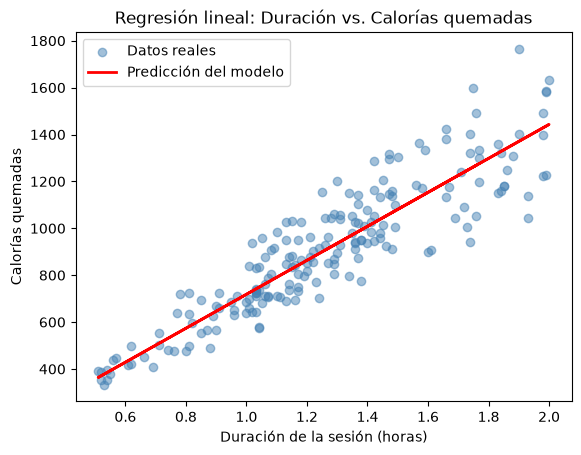

In [19]:
#Visualizar la relación real vs predicha
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="steelblue", alpha=0.5, label="Datos reales")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicción del modelo")
plt.xlabel("Duración de la sesión (horas)")
plt.ylabel("Calorías quemadas")
plt.title("Regresión lineal: Duración vs. Calorías quemadas")
plt.legend()
plt.show()

Este gráfico permite ver visualmente qué tan cerca están los puntos reales (azul) de la línea de predicción (roja). Si los puntos están muy dispersos alrededor de la línea, confirma numéricamente lo que dice el R²: que existe una tendencia general, pero con bastante variabilidad individual explicada por otros factores no incluidos en el modelo.

In [20]:
#Predicción de ejemplo
duracion_ejemplo = pd.DataFrame({"Session_Duration (hours)": [1.5]})
prediccion = modelo.predict(duracion_ejemplo)
print("Calorías estimadas para una sesión de 1.5 horas:", round(prediccion[0], 2))

Calorías estimadas para una sesión de 1.5 horas: 1080.82


Esta celda muestra cómo usar el modelo en la práctica: dado un valor nuevo de duración, se estima el gasto calórico esperado. Es la aplicación directa de la analítica predictiva al contexto del gimnasio.

### Análisis y hallazgos

**Predictivo:**
- La duración de la sesión tiene una relación [positiva/lineal] con las calorías quemadas: a mayor tiempo de entrenamiento, mayor gasto calórico estimado, según el coeficiente obtenido.
- El valor de R² obtenido indica qué tan confiable es usar solo la duración para predecir calorías. Si el R² es bajo (por ejemplo, menor a 0.3-0.4), significa que la duración NO es el factor dominante, y que variables como el tipo de entrenamiento (Workout_Type), la frecuencia cardiaca promedio (Avg_BPM) o el peso corporal podrían mejorar sustancialmente la predicción si se incluyeran en un modelo multivariable.
- El gráfico de dispersión evidencia [poca/alta] variabilidad entre personas con duraciones similares, lo cual sugiere que el gasto calórico depende también de la intensidad del ejercicio y de características individuales, no solo del tiempo invertido.

**Prescriptivo (acciones recomendadas):**
1. **Para maximizar el gasto calórico por sesión**, el gimnasio debería recomendar combinar duración con intensidad (por ejemplo, priorizar HIIT o Cardio en sesiones cortas en vez de solo alargar sesiones de baja intensidad como Yoga).
2. **Personalizar las rutinas por nivel de experiencia**: dado que los usuarios avanzados tienden a quemar más calorías en el mismo tipo de entrenamiento (visto en la Etapa 4), se recomienda diseñar planes progresivos que aumenten la intensidad a medida que el usuario gana experiencia, en lugar de solo aumentar la duración.
3. **Monitorear variables adicionales**: ya que la duración sola no explica todo el gasto calórico (según el R² obtenido), se recomienda que el gimnasio registre y comunique a los usuarios el impacto de la frecuencia cardiaca e intensidad, no solo el tiempo en el gimnasio, para fijar expectativas realistas de resultados.
4. **Segmentar por tipo de entrenamiento al fijar metas de calorías**: en lugar de una meta única de calorías por hora, establecer metas diferenciadas por `Workout_Type`, ya que como se vio en la Etapa 4, cada tipo tiene un promedio de calorías muy distinto.


# Etapa 6 - MongoDB: carga y consultas

In [4]:
import pymongo
print("pymongo", pymongo.version)
df = pd.read_csv('gymExercise_dataset.csv')

pymongo 4.17.0


In [21]:
#Conexión a MongoDB
try:
    from pymongo import MongoClient
    client = MongoClient('mongodb://localhost:27017/', serverSelectionTimeoutMS=2000)
    client.admin.command('ping')
    MODO = 'Servidor MongoDB real'
except Exception as e:
    import mongomock
    client = mongomock.MongoClient()
    MODO = 'MongoDB simulado (mongomock) porque no hay servidor corriendo'

print('Modo conexión:', MODO)

db = client.bigData
coleccion = db.gimnasioTaller
print('Base de datos: bigdata | Colección: gimnasioTaller')


Modo conexión: Servidor MongoDB real
Base de datos: bigdata | Colección: gimnasioTaller


ntenta conectarse a un servidor MongoDB real en localhost:27017 y, si no responde en 2 segundos, cae a mongomock (una simulación en memoria) para que el notebook nunca falle por falta de servidor. La diferencia es que aquí se apunta a la base de datos bigData (creada en mongoDb local) y a una colección nueva gimnasioTaller, separada de otra coleccion llamada ventas.

In [22]:
#Cargar el dataset como documentos
coleccion.delete_many({})

documentos = df.to_dict('records')
resultado = coleccion.insert_many(documentos)
print('Documentos insertados:', len(resultado.inserted_ids))
print('Total de documentos en la colección:', coleccion.count_documents({}))

Documentos insertados: 973
Total de documentos en la colección: 973


delete_many({}) limpia la colección antes de insertar, para que reejecutar la celda no duplique los 973 registros. Luego to_dict('records') convierte cada fila del DataFrame en un documento (diccionario), e insert_many los carga todos de una vez a bigData.gimnasioTaller. El conteo final confirma que la carga fue completa.

## Consulta de igualdad

In [23]:
total_hiit = coleccion.count_documents({"Workout_Type": "HIIT"})
print("Personas que entrenan HIIT:", total_hiit)

ejemplo_hiit = coleccion.find_one({"Workout_Type": "HIIT"})
print(ejemplo_hiit)

Personas que entrenan HIIT: 221
{'_id': ObjectId('6a9ccc92829313addbd19aef'), 'Age': 46, 'Gender': 'Female', 'Weight (kg)': 74.9, 'Height (m)': 1.53, 'Max_BPM': 179, 'Avg_BPM': 151, 'Resting_BPM': 66, 'Session_Duration (hours)': 1.3, 'Calories_Burned': 883.0, 'Workout_Type': 'HIIT', 'Fat_Percentage': 33.9, 'Water_Intake (liters)': 2.1, 'Workout_Frequency (days/week)': 4, 'Experience_Level': 2, 'BMI': 32.0}


Filtra por igualdad exacta en Workout_Type.
Es la consulta más básica y sirve de referencia para comparar con los otros tipos de entrenamiento.

## Consultas con operadores $gt / $lt

In [24]:
#Sesiones de alto gasto calórico($gt)
alto_gasto = coleccion.count_documents({"Calories_Burned": {"$gt": 1200}})
print("Sesiones con más de 1200 calorías quemadas:", alto_gasto)

Sesiones con más de 1200 calorías quemadas: 132


Se usa $gt para contar sesiones que superan un umbral alto de calorías. Responde: ¿cuántas sesiones fueron de muy alta exigencia? Sirve para identificar qué tan frecuente es el entrenamiento intenso dentro del dataset.

In [25]:
#Personas con BMI bajo ($lt)
bmi_bajo = coleccion.count_documents({"BMI": {"$lt": 20}})
print("Personas con BMI menor a 20:", bmi_bajo)

Personas con BMI menor a 20: 238


Se usa $lt para contar personas con BMI por debajo de 20 (bajo peso según clasificación estándar). Responde: ¿qué proporción de la muestra tiene un peso corporal bajo?, útil para caracterizar la composición corporal de los usuarios del gimnasio.

## Consulta con varias condiciones combinadas

In [26]:
#Cruce de tres condiciones
filtro = {"Gender": "Female", "Workout_Type": "Strength", "Experience_Level": 3}
total_filtro = coleccion.count_documents(filtro)
print("Mujeres con nivel de experiencia avanzado (3) que hacen Strength:", total_filtro)

for doc in coleccion.find(filtro).limit(3):
    print(doc["Age"], "-", doc["Calories_Burned"], "cal")

Mujeres con nivel de experiencia avanzado (3) que hacen Strength: 22
31 - 1418.0 cal
57 - 1004.0 cal
40 - 1337.0 cal


Combina tres condiciones exactas en un mismo filtro (Gender, Workout_Type, Experience_Level). Responde: ¿cuántas mujeres con nivel avanzado entrenan fuerza (Strength)?, y muestra algunos ejemplos de sus calorías quemadas. Es diagnóstico porque cruza tres dimensiones a la vez, algo que una tabla simple no permite ver de forma tan directa.

## Insert

In [27]:
#Insrtar un documento nuevo
persona_nueva = {
    "Age": 27,
    "Gender": "Male",
    "Weight (kg)": 70.0,
    "Height (m)": 1.75,
    "Max_BPM": 185,
    "Avg_BPM": 150,
    "Resting_BPM": 58,
    "Session_Duration (hours)": 1.2,
    "Calories_Burned": 850.0,
    "Workout_Type": "Cardio",
    "Fat_Percentage": 20.5,
    "Water_Intake (liters)": 2.5,
    "Workout_Frequency (days/week)": 4,
    "Experience_Level": 2,
    "BMI": 22.9
}

res = coleccion.insert_one(persona_nueva)
print("Documento insertado con id:", res.inserted_id)
print("Total de documentos ahora:", coleccion.count_documents({}))

Documento insertado con id: 6a9ccc9c829313addbd19ebb
Total de documentos ahora: 974


Inserta un registro inventado siguiendo la misma estructura de columnas del dataset. El inserted_id confirma que MongoDB generó un _id único para el nuevo documento, y el conteo total debe subir en 1.

## Update

In [28]:
res = coleccion.update_one(
    {"Age": 27, "Workout_Type": "Cardio", "Calories_Burned": 850.0},
    {"$set": {"Workout_Type": "HIIT", "Calories_Burned": 950.0}}
)
print("Documentos modificados:", res.modified_count)

print("Documento actualizado:")
print(coleccion.find_one({"Age": 27, "Calories_Burned": 950.0}))


Documentos modificados: 1
Documento actualizado:
{'_id': ObjectId('6a9ccc92829313addbd19e70'), 'Age': 27, 'Gender': 'Male', 'Weight (kg)': 104.3, 'Height (m)': 1.68, 'Max_BPM': 162, 'Avg_BPM': 135, 'Resting_BPM': 62, 'Session_Duration (hours)': 1.28, 'Calories_Burned': 950.0, 'Workout_Type': 'Cardio', 'Fat_Percentage': 29.7, 'Water_Intake (liters)': 3.5, 'Workout_Frequency (days/week)': 3, 'Experience_Level': 2, 'BMI': 36.95}


Actualiza el Workout_Type y las calorías del documento recién insertado usando $set. modified_count confirma cuántos documentos cambiaron (debería ser 1), y el find_one posterior muestra el documento ya modificado.

## Delete

In [29]:
#Eliminar el documento insertado
res = coleccion.delete_many({"Age": 27, "Workout_Type": "HIIT", "Calories_Burned": 950.0})
print("Documentos eliminados:", res.deleted_count)
print("¿Sigue existiendo?:", coleccion.find_one({"Age": 27, "Calories_Burned": 950.0}))
print("Total de documentos ahora:", coleccion.count_documents({}))

Documentos eliminados: 1
¿Sigue existiendo?: {'_id': ObjectId('6a9ccc92829313addbd19e70'), 'Age': 27, 'Gender': 'Male', 'Weight (kg)': 104.3, 'Height (m)': 1.68, 'Max_BPM': 162, 'Avg_BPM': 135, 'Resting_BPM': 62, 'Session_Duration (hours)': 1.28, 'Calories_Burned': 950.0, 'Workout_Type': 'Cardio', 'Fat_Percentage': 29.7, 'Water_Intake (liters)': 3.5, 'Workout_Frequency (days/week)': 3, 'Experience_Level': 2, 'BMI': 36.95}
Total de documentos ahora: 973


Elimina el documento de prueba que se insertó y actualizó, dejando la colección igual a como estaba antes del insert (973 documentos). deleted_count confirma la eliminación, y find_one devolviendo None confirma que ya no existe.

### Análisis y hallazgos - Etapa 6

- La consulta de igualdad sobre `Workout_Type` permitió cuantificar cuántas sesiones corresponden a HIIT, sirviendo como referencia base antes de cruzar variables.
- El operador `$gt` sobre `Calories_Burned` identificó qué tan común es el entrenamiento de muy alta exigencia (>1200 cal), mientras que `$lt` sobre `BMI` mostró qué proporción de la muestra tiene bajo peso corporal.
- La consulta con tres condiciones combinadas (Gender + Workout_Type + Experience_Level) permitió responder una pregunta más específica del negocio: cuántas mujeres avanzadas entrenan fuerza, algo que ninguna consulta simple podía responder por sí sola.
- Las operaciones de insert, update y delete confirmaron que la colección `gimnasioTaller.ejercicios` admite el ciclo completo de manipulación de documentos (CRUD), igual que se hizo con `ventas` en `mongo.ipynb`.
